In [ ]:
import pandas as pd
import joblib
import os
from google.colab import drive
drive.mount('/content/drive')
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
import matplotlib.pyplot as plt
import seaborn as sns

# Carga de modelos
ruta_models = '/content/drive/MyDrive/Smoking_prediction_models/'
rf_modelo = joblib.load(os.path.join(ruta_models, 'rf_global_final.pkl'))
stack_modelo = joblib.load(os.path.join(ruta_models, 'Stacking_model.pkl'))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split

# 1. Cargamos el dataset procesado
df = pd.read_csv('/content/drive/My Drive/Training_And_Testing_Dataset/smoking_prediction_processed.csv')

# 2. Eliminamos las constantes (igual que en el entrenamiento)
cols_const = [c for c in df.columns if df[c].nunique() <= 1]
df = df.drop(columns=cols_const)

# 3. Definimos variables
X = df.drop(columns=['ID', 'smoking'])
y = df['smoking']

# 4. VOLVEMOS A HACER EL SPLIT (¡Importante!)
# Usamos el mismo random_state=42 para que el test sea exactamente el mismo
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("✅ Datos de validación listos.")

✅ Datos de validación listos.


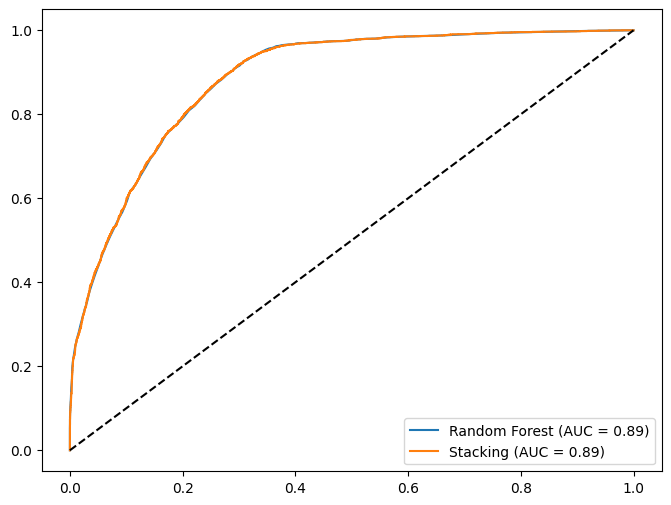

In [ ]:
# Ejemplo para la Curva ROC
def plot_roc(y_true, y_prob, label):
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    plt.plot(fpr, tpr, label=f'{label} (AUC = {auc(fpr, tpr):.2f})')

plt.figure(figsize=(8,6))
plot_roc(y_test, rf_modelo.predict_proba(X_test)[:,1], 'Random Forest')
plot_roc(y_test, stack_modelo.predict_proba(X_test)[:,1], 'Stacking')
plt.plot([0, 1], [0, 1], 'k--')
plt.legend()
plt.show()

--- Reporte de Clasificación (Random Forest) ---
              precision    recall  f1-score     support
0              0.852050  0.830123  0.840944   6334.0000
1              0.718987  0.750955  0.734623   3666.0000
accuracy       0.801100  0.801100  0.801100      0.8011
macro avg      0.785518  0.790539  0.787783  10000.0000
weighted avg   0.803269  0.801100  0.801967  10000.0000


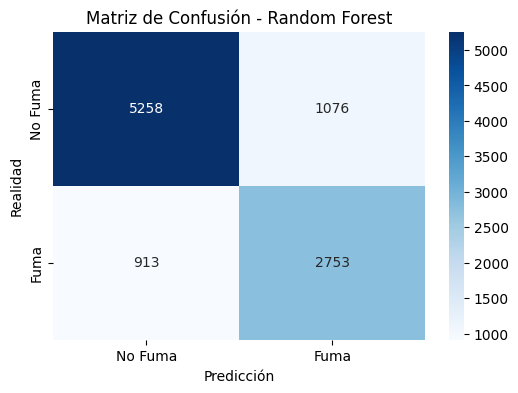

In [ ]:
# ==========================================
# 05_validacion.ipynb - Resumen Estadístico
# ==========================================
from sklearn.metrics import classification_report, confusion_matrix
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Generamos predicciones finales con tu mejor modelo (RF)
y_pred_rf = rf_modelo.predict(X_test)

# 2. Tabla de métricas (Precision, Recall, F1, Accuracy)
print("--- Reporte de Clasificación (Random Forest) ---")
report = classification_report(y_test, y_pred_rf, output_dict=True)
df_report = pd.DataFrame(report).transpose()
print(df_report)

# 3. Matriz de Confusión Visual
plt.figure(figsize=(6, 4))
cm = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Fuma', 'Fuma'],
            yticklabels=['No Fuma', 'Fuma'])
plt.xlabel('Predicción')
plt.ylabel('Realidad')
plt.title('Matriz de Confusión - Random Forest')
plt.show()

--- Reporte de Clasificación (Stacking) ---
              precision    recall  f1-score     support
0              0.848199  0.836280  0.842197   6334.0000
1              0.723835  0.741408  0.732516   3666.0000
accuracy       0.801500  0.801500  0.801500      0.8015
macro avg      0.786017  0.788844  0.787357  10000.0000
weighted avg   0.802607  0.801500  0.801988  10000.0000


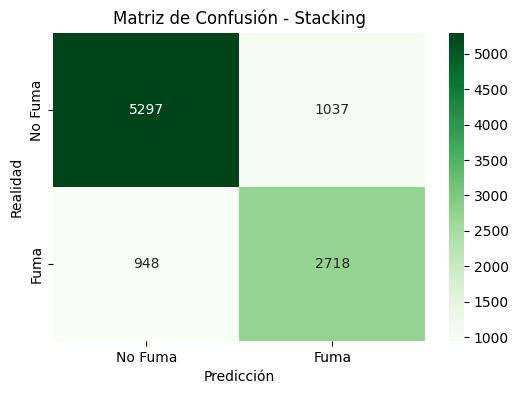

In [ ]:
# ==========================================
# 05_validacion.ipynb - Resumen Stacking
# ==========================================

# 1. Generamos predicciones con el modelo de Stacking
y_pred_stack = stack_modelo.predict(X_test)

# 2. Reporte de Clasificación detallado
print("--- Reporte de Clasificación (Stacking) ---")
report_stack = classification_report(y_test, y_pred_stack, output_dict=True)
df_report_stack = pd.DataFrame(report_stack).transpose()
print(df_report_stack)

# 3. Matriz de Confusión Visual
plt.figure(figsize=(6, 4))
cm_stack = confusion_matrix(y_test, y_pred_stack)
sns.heatmap(cm_stack, annot=True, fmt='d', cmap='Greens', # Usamos verde para diferenciarlo del azul del RF
            xticklabels=['No Fuma', 'Fuma'],
            yticklabels=['No Fuma', 'Fuma'])
plt.xlabel('Predicción')
plt.ylabel('Realidad')
plt.title('Matriz de Confusión - Stacking')
plt.show()

-El Random Forest demuestra una mayor capacidad de Recall (menores falsos negativos), lo que lo hace ideal si el objetivo fuera detectar a la mayor cantidad posible de fumadores para un programa de salud preventiva.

-El Stacking presenta una Precision ligeramente superior (menores falsos positivos), lo que significa que es un poco más 'estricto' y confiable cuando marca a alguien como fumador.